### Libraries

In [1]:
#!pip install nltk

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F, types as T
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.recommendation import ALS
from pyspark.ml.regression import LinearRegression,RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator, MulticlassClassificationEvaluator
from pyspark.sql.types import ArrayType, StringType
import matplotlib.pyplot as plt
import re
import pandas as pd
import numpy as np
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/jovyan/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

#### Loading Data from HDFS

In [3]:
ss = SparkSession.builder.appName("infs3208project").getOrCreate()

In [4]:
books_data_path = "hdfs://namenode:9000/books_data.csv"
books_rating_path = "hdfs://namenode:9000/Books_rating.csv"

In [5]:
#books data
df_bd = (
    ss.read.option("header", "true")
    .option("quote", "\"")       
    .option("escape", "\"")      
    .option("multiLine", True)   
    .csv(books_data_path)
)


#books ratings
df_br = (
    ss.read.option("header", "true")
    .option("quote", "\"")       
    .option("escape", "\"")      
    .option("multiLine", True)   
    .csv(books_rating_path)
)

In [6]:
#saving dataframes as a parquet file for fast re-use of data
cols_bd = ["title","authors", "categories"]
cols_br = ["Id", "Title","User_id", "review/score", "review/helpfulness","review/summary"]
(df_bd.select(*cols_bd).write.mode("overwrite").option("compression","snappy").parquet("/tmp/df_bd_pq"))
(df_br.select(*cols_br).write.mode("overwrite").option("compression","snappy").parquet("/tmp/df_br_pq"))


In [7]:
df_bd = ss.read.parquet("/tmp/df_bd_pq")
df_br = ss.read.parquet("/tmp/df_br_pq")

In [8]:
row_count1 = df_bd .count()
row_count2 = df_br .count()
print("# Rows in df_bd:", row_count1)
print("# Rows in df_br:", row_count2)

# Rows in df_bd: 212404
# Rows in df_br: 3000000


# Data Pre-processing

#### Filtering Books_ratings data with only fiction books

In [9]:

#Filtering books data by Fiction and children stories
df_bd_fiction = (
    df_bd
    #make title column lowercase
    .withColumn("title_lc", F.lower(F.trim(F.col("title"))))
    #make category column lowercase
    .withColumn("cat_lc",   F.lower(F.trim(F.col("categories").cast("string"))))
    #fitler rows that contain blank or null titles
    .filter(F.col("title_lc").isNotNull() & (F.col("title_lc") != ""))
    #filter for books that are fiction
    .filter(
        (F.col("cat_lc").contains("fiction") | F.col("cat_lc").contains("children")) &
        ~(F.col("cat_lc").rlike(r"non[- ]?fiction") | F.col("cat_lc").contains("nonfiction"))
    )
)

#Create a dataframe that only contains unique titles by authors
df_bd_unique = (
    df_bd_fiction 
    .select("title_lc", F.col("title").alias("title_original"), "authors")
    .dropDuplicates(["title_lc"])
)
#creates dataframe that only contains unique titles
df_fiction_titles = df_bd_unique.select(F.col("title_lc").alias("Title"))

#inner joining books rating data to be filtered by unique fiction titles
df_br_filtered = (
    df_br
    .withColumn("Title", F.lower(F.trim(F.col("Title"))))
    .join(df_fiction_titles, on="Title", how="inner")
)

#Row count check
row_count = df_br_filtered.count()
print("# Rows in df_br after filtering to fiction (excluding nonfiction):", row_count)

# Rows in df_br after filtering to fiction (excluding nonfiction): 1134688


#### Processing quantitative columns and filtering with titles that contain atleast 1000 reviews

In [10]:
# counting number of reviews per title
df_review_counts = (
    df_br_filtered
    .groupBy("Title")
    .agg(F.count("*").alias("num_reviews"))
)

# Inner Joinning the counts back and keep only titles with ≥ 1000 reviews
df_br_filtered_1000 = (
    df_br_filtered
    .join(df_review_counts, on="Title", how="inner")
    .filter(F.col("num_reviews") >= 1000)
)


df_br_ratings_clean = (
    df_br_filtered_1000
    #ensure book review has a score
    .filter(F.col("review/score").isNotNull() & (F.col("review/score") != ""))
    #ensure book review was a notable review
    .filter(F.col("review/helpfulness").isNotNull() & (F.col("review/helpfulness") != ""))
    #ensure helpfulness column is not empty
    .filter(F.col("review/helpfulness").rlike(r"^\d+/\d+$"))
    #ensures rating score is data type of double
    .withColumn("rating", F.col("review/score").cast("double"))
    #retrieve votes of helpfulness column
    .withColumn("helpful_votes", F.split(F.col("review/helpfulness"), "/").getItem(0).cast("double"))
     #retrieve total possible votes of helpfulness column
    .withColumn("total_votes", F.split(F.col("review/helpfulness"), "/").getItem(1).cast("double"))
    #create helpfulness ratio
    .withColumn("helpfulness_ratio",
        F.when(F.col("total_votes") > 0, F.col("helpful_votes") / F.col("total_votes"))
         .otherwise(0.0)
    )
    #ensures that rating is between 1 and 5. 
    .filter((F.col("rating") >= 0) & (F.col("rating") <= 5.0))
)


df_br_ratings_clean = df_br_ratings_clean.filter((F.col("total_votes") >= 1) & (F.col("helpfulness_ratio") >= 0.5))

#check to see how many rows is filtered to
row_count = df_br_ratings_clean.count()
print("# Rows in df_br_ratings_clean after filtering to 1000 rows per title:", row_count)

#deletes unused dataframes
del df_br
del df_bd
del df_bd_fiction
del df_br_filtered
del df_br_filtered_1000



#saving dataframe as a parquet file for fast re-use of data
(df_br_ratings_clean
 .write.mode("overwrite").option("compression","snappy")
 .parquet("/tmp/reviews_filtered_fiction"))  

# Rows in df_br_ratings_clean after filtering to 1000 rows per title: 137028


In [11]:
df_br_ratings_clean = ss.read.parquet("/tmp/reviews_filtered_fiction")

####  Text Processing For Sentiment Analysis

In [12]:

# Makes sure there is text in summary section
df_br_text_clean = df_br_ratings_clean.filter(
    F.col("review/summary").isNotNull() &
    (F.length(F.trim(F.col("review/summary"))) > 0)
)

# removes punction,special
df_br_clean = df_br_text_clean.withColumn(
    "review_summary_clean",
    #lowers capitilisation
    F.lower(
        #trims data
        F.trim(
            F.regexp_replace(                     
                F.regexp_replace(                  
                    F.col("review/summary"),
                    #keep only letters,numbers and apostorphes. Removes special characters and punctuation
                    r"[^\p{L}\p{N}\s']",
                    " "
                ),
                #limits white spaces
                r"\s+",
                " "
            )
        )
    )
)   
    
row_count = df_br_clean.count()
print("# Rows in df_br_clean after text processing:", row_count)


# Rows in df_br_clean after text processing: 137028


In [13]:
del df_br_text_clean
del df_br_ratings_clean

# Analytical Task 1 - Colloborative Filtering (ALS)

####  Table prep for ALS

In [14]:
#Filters dataset for column user_id,title and ratings
df_ratings = (
    df_br_clean
    .select(
        F.col("User_id").alias("user_str"),
        F.col("Title").alias("item_str"),
        F.col("rating").cast("double")  
    )
    .dropna(subset=["user_str","item_str","rating"])
)

#### creating numerical index for user and title strings

In [15]:

#converts string ids to numerical ids
df_user_indexer = StringIndexer(inputCol="user_str", outputCol="userId", handleInvalid="skip").fit(df_ratings)
df_title_indexer = StringIndexer(inputCol="item_str", outputCol="itemId", handleInvalid="skip").fit(df_ratings)

#create ratings dataframe to contain numerical ids
df_ratings_indexed = (
    df_title_indexer.transform(df_user_indexer.transform(df_ratings))
    .select("userId","itemId","rating")
    .cache()
)

#### creating training and test datasets

In [16]:
#creating training and test sets
train, test = df_ratings_indexed.randomSplit([0.8, 0.2], seed=42)

#### creating and evaluating als model

In [17]:
#ALS model
als = ALS(
    userCol="userId", itemCol="itemId", ratingCol="rating",
    nonnegative=True, implicitPrefs=False, 
    rank=64, regParam=0.08, maxIter=15,
    coldStartStrategy="drop"  
)

#fitting Model
model = als.fit(train)

# Evaulation
pred = model.transform(test)
rmse = RegressionEvaluator(metricName="rmse", labelCol="rating", predictionCol="prediction").evaluate(pred)
mae = RegressionEvaluator(metricName="mae", labelCol="rating", predictionCol="prediction").evaluate(pred)
r2 = RegressionEvaluator(metricName="r2", labelCol="rating", predictionCol="prediction").evaluate(pred)
mse = RegressionEvaluator(metricName="mse", labelCol="rating", predictionCol="prediction").evaluate(pred)
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R2: {r2:.4f}")
print(f"MSE: {mse:.4f}")

RMSE: 0.3337
MAE: 0.1612
R2: 0.8762
MSE: 0.1113


#### recommending 50 books to each user

In [18]:
# find top 50 book recommendations per user
df_user_recs = model.recommendForAllUsers(50)

# exploding df_user_recs and keeping (userId, itemId, predicted_rating)
df_user_recs_exploded = (
    df_user_recs
    .withColumn("rec", F.explode("recommendations"))
    .select("userId",
            F.col("rec.itemId").alias("itemId"),
            F.col("rec.rating").alias("predicted_rating"))
)

# Counting how many times each item appears in top-50 lists
df_title_counts = (
    df_user_recs_exploded
    .groupBy("itemId")
    .agg(F.count("*").alias("times_recommended"),
         F.avg("predicted_rating").alias("avg_pred_score"))
    .orderBy(F.col("times_recommended").desc(), F.col("avg_pred_score").desc())
)

#### Counting which books are recommended the most

In [19]:
# creating numerical index and title dataframe for lookup
df_title_map = ss.createDataFrame(
    [(float(i), lab) for i, lab in enumerate(df_title_indexer.labels)],  
    ["itemId", "Title"]
)

#joining titles back to dataframe
df_top_titles = (
    df_title_counts
    .withColumn("itemId", F.col("itemId").cast("double"))
    .join(df_title_map, on="itemId", how="left")
    .select("Title", "itemId", "times_recommended", "avg_pred_score")
    .orderBy(F.col("times_recommended").desc(), F.col("avg_pred_score").desc())
)

#top 10 recommended books
df_top10 = df_top_titles.limit(10)
df_top10.show(truncate=False)

+----------------------------------------------+------+-----------------+------------------+
|Title                                         |itemId|times_recommended|avg_pred_score    |
+----------------------------------------------+------+-----------------+------------------+
|the fellowship of the ring                    |136.0 |29791            |3.530498130066366 |
|the two towers                                |77.0  |29318            |3.500583010618371 |
|lonesome dove                                 |100.0 |29259            |3.58978216387511  |
|the giver                                     |18.0  |27891            |3.453223770305283 |
|charlotte's web                               |99.0  |27455            |3.4820969926401295|
|1984                                          |13.0  |26977            |3.4740226070933122|
|a clockwork orange                            |74.0  |26546            |3.45331118799842  |
|the grapes of wrath                           |76.0  |26344          

#### Counting which authors are recommended the most

In [20]:
#adjust column name
df_top_titles = df_top_titles.withColumn("title_lc", F.lower(F.trim(F.col("Title"))))

# Joining back authors to top titles
df_authors = (
    df_top_titles
    .join(df_bd_unique.select("title_lc", "authors"), on="title_lc", how="left")
)


# Defines the data type that is for authors column
arr_t = T.ArrayType(T.StringType())

df_titles_with_authors = (
    df_authors
    # Create a unified "authors_arr" column that handles all possible input formats
    .withColumn(
        "authors_arr",
        F.coalesce(  # coalesce picks the first non-null result among the expressions below

            # Parses json array
            F.from_json(F.col("authors").cast("string"), arr_t),

            # cleans up brackets/quotes and split by commas
            F.split(
                # Removing brackets and remove quotes
                F.regexp_replace(
                    # Remove quotes
                    F.regexp_replace(F.col("authors").cast("string"),
                                     r"^\s*\[|\]\s*$", ""),  
                    r"""["']""", ""                            
                ),
                r"\s*,\s*"  
            )
        )
    )
)

# Explode and processes authors
df_authors_exploded = (
    df_titles_with_authors
    .withColumn("author", F.explode_outer("authors_arr"))
    .withColumn("author", F.trim(F.col("author")))
    .filter(F.col("author").isNotNull() & (F.col("author") != ""))
)

# Aggregates votes per author
df_top_authors = (
    df_authors_exploded
    .groupBy("author")
    .agg(
        F.sum("times_recommended").alias("author_votes"),
        F.countDistinct("Title").alias("unique_books_contributing")
    )
    .orderBy(F.col("author_votes").desc(), F.col("unique_books_contributing").desc())
    .limit(10)
)

df_top_authors.show(truncate=False)

+-------------------------+------------+-------------------------+
|author                   |author_votes|unique_books_contributing|
+-------------------------+------------+-------------------------+
|Charles Dickens          |98017       |4                        |
|George Orwell            |78540       |3                        |
|John Steinbeck           |73226       |5                        |
|Kurt Vonnegut            |53302       |4                        |
|J.R.R. Tolkien           |38953       |2                        |
|John Ronald Reuel Tolkien|37290       |2                        |
|Charlotte Brontë         |37273       |2                        |
|Mark Twain               |33342       |3                        |
|Lewis Carroll            |31888       |2                        |
|J. K. Rowling            |29619       |2                        |
+-------------------------+------------+-------------------------+



### Visualisations of Model and Results

#### Predicted vs Actual rating scatter

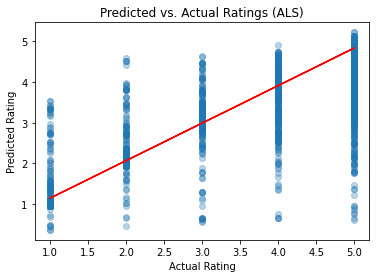

Slope: 0.923, Intercept: 0.219


In [21]:



df_pred = pred.select("rating", "prediction").toPandas()
# convert to numpy arrays
x = df_pred["rating"]
y = df_pred["prediction"]

# fit a linear regression line y = a*x + b
a, b = np.polyfit(x, y, 1)

# scatter plot of actual vs predicted
plt.scatter(x, y, alpha=0.3)
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Predicted vs. Actual Ratings (ALS)")

# add regression line
plt.plot(x, a*x + b, color="red", label=f"Trend line: y={a:.2f}x+{b:.2f}")

plt.show()

print(f"Slope: {a:.3f}, Intercept: {b:.3f}")

#### Residual Plot

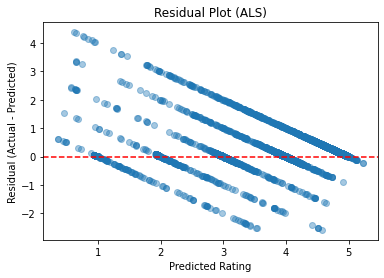

In [22]:
df_pred["residual"] = df_pred["rating"] - df_pred["prediction"]

#residual plot
plt.scatter(df_pred["prediction"], df_pred["residual"], alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Rating")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot (ALS)")
plt.show()

#### Distribution of residuals

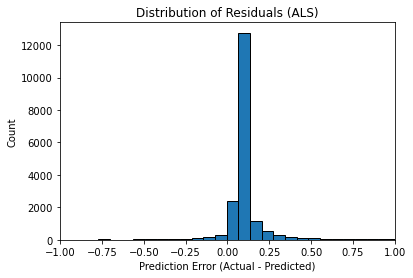

In [23]:
#distribution of residuals
plt.hist(df_pred["residual"], bins=100, edgecolor='black')
plt.xlabel("Prediction Error (Actual - Predicted)")
plt.ylabel("Count")
plt.title("Distribution of Residuals (ALS)")
plt.xlim(-1, 1)
plt.show()

#### Top 10 Recommended Books

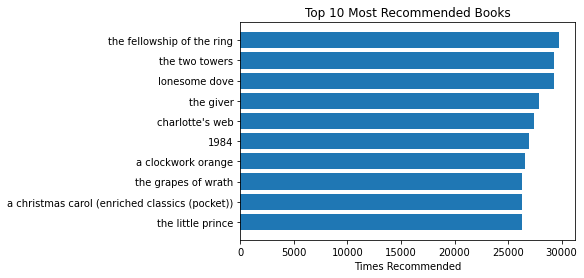

In [24]:
top_titles_pd = df_top_titles.toPandas()
plt.barh(top_titles_pd["Title"].head(10), top_titles_pd["times_recommended"].head(10))
plt.xlabel("Times Recommended")
plt.title("Top 10 Most Recommended Books")
plt.gca().invert_yaxis()
plt.show()


#### Top 10 Recommended Authors

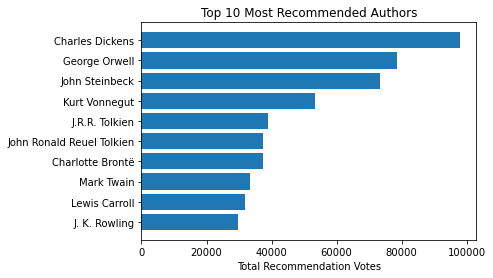

In [25]:
top_authors_pd = df_top_authors.toPandas()
plt.barh(top_authors_pd["author"].head(10), top_authors_pd["author_votes"].head(10))
plt.xlabel("Total Recommendation Votes")
plt.title("Top 10 Most Recommended Authors")
plt.gca().invert_yaxis()
plt.show()

In [26]:
del df_ratings, df_ratings_indexed
del train, test, pred    
del df_user_recs, df_user_recs_exploded
del df_title_counts, df_title_map, df_top_titles, df_top10
del df_authors, df_titles_with_authors, df_authors_exploded, df_top_authors
del df_user_indexer, df_title_indexer, model


# Analytical Task 2  - Sentiment Analysis

#### Load in Sentiment analysis model

In [27]:

#loads VADERS pre-trained lexicon
sia = SentimentIntensityAnalyzer()

#computes sentiment score
def vader_score(text):
    return sia.polarity_scores(text)['compound']

#reutrnes double datatype for sentiment score
vader_udf = F.udf(vader_score, T.DoubleType())

#### apply sentiment analysis to review text

In [28]:
#apply sentiment analysis to preprocesssed review text and provide it with sentiment lables
#pd dataframe
df_sentiment_pd = (
    df_br_clean
    .withColumn("sentiment", vader_udf(F.col("review_summary_clean")))
    .withColumn(
        "sentiment_label",
        F.when(F.col("sentiment") >= 0.05, "positive")
         .when(F.col("sentiment") <= -0.05, "negative")
         .otherwise("neutral")
    )
    .select("sentiment", "sentiment_label")
    .toPandas()
)

#spark dataframe
df_sentiment = (
    df_br_clean
    .withColumn("sentiment", vader_udf(F.col("review_summary_clean")))
    .withColumn(
        "sentiment_label",
        F.when(F.col("sentiment") >= 0.05, "positive")
         .when(F.col("sentiment") <= -0.05, "negative")
         .otherwise("neutral")
    )
    
)

#### visualise distribution of sentiment labels

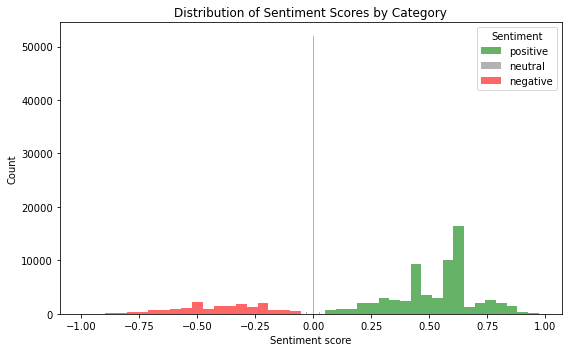

In [29]:
#plots distribution of sentiment scores
plt.figure(figsize=(8,5))
colors = {"positive": "green", "neutral": "gray", "negative": "red"}
for label, color in colors.items():
    subset = df_sentiment_pd[df_sentiment_pd["sentiment_label"] == label]
    plt.hist(
        subset["sentiment"], bins=20, alpha=0.6,
        label=label, color=color
    )

plt.xlabel("Sentiment score")
plt.ylabel("Count")
plt.title("Distribution of Sentiment Scores by Category")
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

In [30]:
del sia
del vader_udf
del df_br_clean

# Analytical Task 3  - Linear Regression on Sentiment

#### extract feature columns and create vector assembler

In [31]:
#features used in model
feature_cols = ["sentiment", "total_votes", "helpfulness_ratio", "num_reviews", "helpful_votes"]
#creates vector assemble and dataframe
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
df_ml = assembler.transform(df_sentiment).select("rating", "features")

#### creating training and test datasets

In [32]:
train, test = df_ml.randomSplit([0.8, 0.2], seed=42)

#### creating and evaluating linear regression model on sentiment scores

In [33]:
#fitting the model
lr = LinearRegression(featuresCol="features", labelCol="rating")
model = lr.fit(train)
print("Coefficients:", model.coefficients)
print("Intercept:", model.intercept)

Coefficients: [0.8124473864816947,-0.06296860581851257,0.6917743996260005,2.0345883310585143e-05,0.06726533501556746]
Intercept: 3.554893335974734


#### evaluation

In [34]:
pred = model.transform(test)
# Evaulation
rmse = RegressionEvaluator(metricName="rmse", labelCol="rating", predictionCol="prediction").evaluate(pred)
mae = RegressionEvaluator(metricName="mae", labelCol="rating", predictionCol="prediction").evaluate(pred)
r2 = RegressionEvaluator(metricName="r2", labelCol="rating", predictionCol="prediction").evaluate(pred)
mse = RegressionEvaluator(metricName="mse", labelCol="rating", predictionCol="prediction").evaluate(pred)
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R2: {r2:.4f}")
print(f"MSE: {mse:.4f}")

RMSE: 1.0037
MAE: 0.7378
R2: 0.1625
MSE: 1.0074


### Visualisations for Linear Regression Model

#### Predicted vs Actual rating scatter

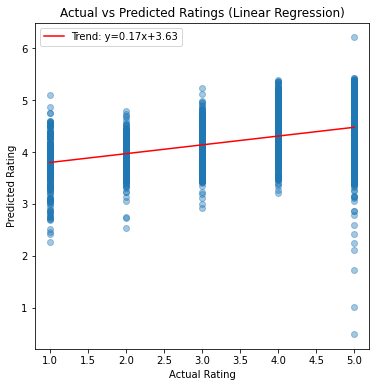

In [35]:
# creating dataframe for predictions
df_pred = pred.select("rating", "prediction").sample(False, 0.2, seed=42).toPandas()
df_pred_filtered = df_pred[df_pred["prediction"] >= 0]

# Refit line and plot using the filtered data
a, b = np.polyfit(df_pred_filtered["rating"], df_pred_filtered["prediction"], 1)

#scatter plot of predicted vs actual rating scatter
plt.figure(figsize=(6,6))
plt.scatter(df_pred_filtered["rating"], df_pred_filtered["prediction"], alpha=0.4)
plt.plot(df_pred_filtered["rating"], a*df_pred_filtered["rating"] + b,color="red", label=f"Trend: y={a:.2f}x+{b:.2f}")
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Ratings (Linear Regression)")
plt.legend()
plt.show()

#### Residuals plot

<ipython-input-36-d2cd8c7e7847>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pred_filtered["residual"] = df_pred_filtered["rating"] - df_pred_filtered["prediction"]


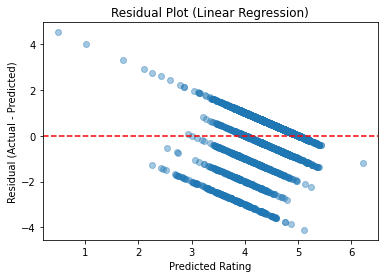

In [36]:
df_pred_filtered["residual"] = df_pred_filtered["rating"] - df_pred_filtered["prediction"]

#residual plot
plt.scatter(df_pred_filtered["prediction"], df_pred_filtered["residual"], alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Rating")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot (Linear Regression)")
plt.show()

#### Distribution of residuals 

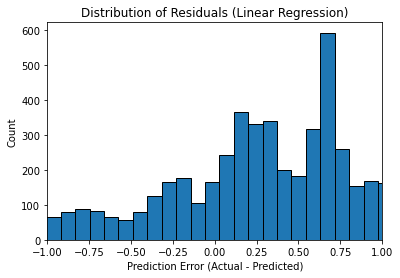

In [37]:
#Distribution of residuals plot
plt.hist(df_pred_filtered["residual"], bins=100, edgecolor='black')
plt.xlabel("Prediction Error (Actual - Predicted)")
plt.ylabel("Count")
plt.title("Distribution of Residuals (Linear Regression)")
plt.xlim(-1, 1)
plt.show()

In [38]:
del lr
del model
del df_pred_filtered
del df_pred

# # Analytical Task 4 - Random Forest Regressor

In [39]:
#fitting the model
rf = RandomForestRegressor(featuresCol="features",labelCol="rating",numTrees=100,maxDepth=8,seed=42)
model = rf.fit(train)

#### evaluation

In [40]:
pred = model.transform(test)
#evaluation
rmse = RegressionEvaluator(metricName="rmse", labelCol="rating", predictionCol="prediction").evaluate(pred)
mae = RegressionEvaluator(metricName="mae", labelCol="rating", predictionCol="prediction").evaluate(pred)
r2 = RegressionEvaluator(metricName="r2", labelCol="rating", predictionCol="prediction").evaluate(pred)
mse = RegressionEvaluator(metricName="mse", labelCol="rating", predictionCol="prediction").evaluate(pred)
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R2: {r2:.4f}")
print(f"MSE: {mse:.4f}")

RMSE: 0.8917
MAE: 0.6586
R2: 0.3389
MSE: 0.7952


### Visualisations for Random Forest Regressor

#### Predicted vs Actual rating scatter

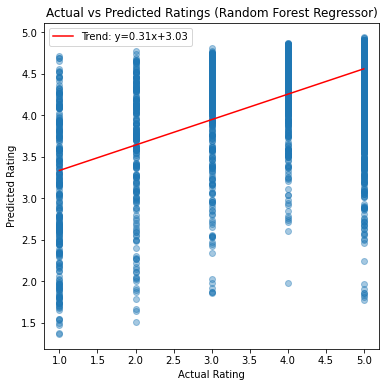

In [41]:
# creating dataframe for predictions
df_pred = pred.select("rating", "prediction").sample(False, 0.2, seed=42).toPandas()
df_pred_filtered = df_pred[df_pred["prediction"] >= 0]

# Refit line and plot using the filtered data
a, b = np.polyfit(df_pred_filtered["rating"], df_pred_filtered["prediction"], 1)

#scatter plot of predicted vs actual rating scatter
plt.figure(figsize=(6,6))
plt.scatter(df_pred_filtered["rating"], df_pred_filtered["prediction"], alpha=0.4)
plt.plot(df_pred_filtered["rating"], a*df_pred_filtered["rating"] + b,color="red", label=f"Trend: y={a:.2f}x+{b:.2f}")
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Ratings (Random Forest Regressor)")
plt.legend()
plt.show()

#### Residuals plot

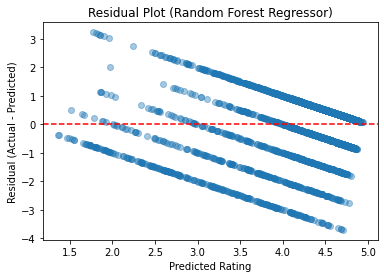

In [42]:
df_pred_filtered["residual"] = df_pred_filtered["rating"] - df_pred_filtered["prediction"]

#residual plot
plt.scatter(df_pred_filtered["prediction"], df_pred_filtered["residual"], alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Rating")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot (Random Forest Regressor)")
plt.show()

#### Distribution of Residuals

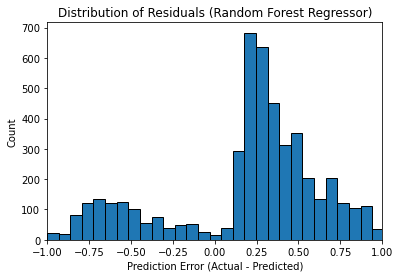

In [43]:
#Distribution of residuals plot
plt.hist(df_pred_filtered["residual"], bins=100, edgecolor='black')
plt.xlabel("Prediction Error (Actual - Predicted)")
plt.ylabel("Count")
plt.title("Distribution of Residuals (Random Forest Regressor)")
plt.xlim(-1, 1)
plt.show()

In [44]:
ss.stop()